In [1]:
import os
import glob
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm

# --- CONFIGURATION ---
ROOT_DIR = Path("/kaggle/input")
OUTPUT_DIR = Path("/kaggle/working/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# --- MAPPING BRAIN (V10: TURKISH-INDIAN FUSION) ---
LABEL_MAP = {
    # === 1. INDIAN MAJOR CARPS ===
    'rohu': 'rohu', 'labeo rohita': 'rohu',
    'catla': 'catla',
    'mrigal': 'mrigal',
    
    # === 2. MARKET STAPLES (Expanded) ===
    'tilapia': 'tilapia',
    'pangasius': 'catfish', 'catfish': 'catfish',
    'hilsa': 'hilsa',
    'barramundi': 'barramundi', 'bhetki': 'barramundi', 
    'sea bass': 'barramundi', # Map Turkish Sea Bass to Bhetki (Close enough for Hackathon)
    
    # === 3. MARINE & EXPORT ===
    # Mackerel Group (Bangda + Horse Mackerel)
    'mackerel': 'mackerel', 'rastrelliger': 'mackerel', 'horse mackerel': 'mackerel',
    
    # Pomfret Group
    'pomfret': 'pomfret', 'black pomfret': 'black_pomfret', 
    
    # Seer Fish Group (The Holy Grail)
    'seer': 'seer_fish', 'scomberomorus': 'seer_fish', 'spanish mackerel': 'seer_fish',
    
    # New Additions
    'red mullet': 'red_mullet', # Nagarai
    'trout': 'trout',
    'black sea sprat': 'sardine', # Map Sprat to Sardine (Visual proxy)
    'striped red mullet': 'red_mullet',
    'gilt head bream': 'sea_bream', # New Class
    'red sea bream': 'sea_bream',
    
    # === 4. CRUSTACEANS ===
    'prawn': 'prawn', 'shrimp': 'prawn', 
    'crab': 'crab', 'mud_crab': 'crab',
    
    # === 5. STATUS ===
    'healthy': 'healthy', 'fresh': 'healthy',
    'white_spot': 'white_spot_virus', 'wssv': 'white_spot_virus',
    'black_gill': 'black_gill_disease',
    'fresh_eyes': 'fresh_eye', 'fresh_gills': 'fresh_gill',
    'nonfresh_eyes': 'stale_eye', 'nonfresh_gills': 'stale_gill'
}

metadata = []

# SEARCH LIST
# We prioritize your "fishnet-dataset" upload
# Updated Search List
SCAN_TARGETS = [
    ("fish-classification", "freshness_quality"), # Freshness
    ("large-scale-fish", "species_market_turkish"), # <--- NEW DATASET
    ("bangaladeshi-fish", "species_market"),
    ("indian-seafood", "species_market_indian"),
    ("shrimp-disease", "shrimp_disease"),
    ("fishnet", "wild_background_benchmark"),
    ("crab", "crab_dataset")
]

print("🚀 Starting Hunter-Seeker (Final Indian Edition)...")

processed_paths = set() # Prevent duplicate scanning

for dataset_keyword, source_tag in SCAN_TARGETS:
    # Find matching folders in Input
    found_roots = list(ROOT_DIR.glob(f"**/*{dataset_keyword}*"))
    
    for search_root in found_roots:
        if str(search_root) in processed_paths: continue
        processed_paths.add(str(search_root))
        
        print(f"🔎 Scanning: {search_root.name}...")
        
        valid_exts = {'.jpg', '.jpeg', '.png', '.bmp'}
        all_files = [p for p in search_root.rglob("*") if p.suffix.lower() in valid_exts]
        
        count = 0
        for img_path in tqdm(all_files, desc=search_root.name[:15], leave=False):
            folder = img_path.parent.name.lower()
            
            row = {
                'path': str(img_path),
                'type': 'unknown', 'label': 'unknown',
                'species_label': 'unknown', 'disease_label': 'unknown', 'freshness_score': -1.0
            }
            
            # --- 1. CRUSTACEANS (Dual Identity) ---
            if "shrimp" in source_tag or "prawn" in folder:
                row['type'] = 'dual'
                row['species_label'] = 'prawn'
                d_label = 'healthy'
                if 'white_spot' in folder or 'wssv' in folder: d_label = 'white_spot_virus'
                elif 'black_gill' in folder or 'bg' in folder: d_label = 'black_gill_disease'
                row['disease_label'] = d_label
                row['label'] = d_label

            # --- 2. FRESHNESS ---
            elif "freshness" in source_tag:
                row['type'] = 'freshness'
                row['species_label'] = 'unknown'
                if 'fresh' in folder and 'non' not in folder: row['freshness_score'] = 1.0
                elif 'stale' in folder or 'non' in folder: row['freshness_score'] = 0.0
                else: continue
                row['label'] = 'freshness_sample'

            # --- 3. SPECIES (The Main Event) ---
            else:
                if "wild" in source_tag and count > 8000: continue 
                
                matched = False
                for k, v in LABEL_MAP.items():
                    if k in folder:
                        row['type'] = 'species'
                        row['species_label'] = v
                        row['label'] = v
                        matched = True
                        break
                
                # Fallback for Wild Background
                if not matched and ("wild" in source_tag or "fishnet" in str(search_root).lower()):
                    row['type'] = 'species'
                    row['species_label'] = 'wild_fish_background'
                    row['label'] = 'wild_fish_background'
                    matched = True
                
                if not matched: continue

            metadata.append(row)
            count += 1
            
        print(f"   ✅ Captured {count} images.")

if metadata:
    df = pd.DataFrame(metadata)
    df.to_csv(OUTPUT_DIR / "metadata_kaggle_fused.csv", index=False)
    print("\n🏆 FUSION COMPLETE.")
    print("--- FINAL SPECIES ROSTER ---")
    # Filter out unknown and background to see the real fish count
    real_fish = df[~df['species_label'].isin(['unknown', 'wild_fish_background'])]
    print(real_fish['species_label'].value_counts().head(40))
else:
    print("❌ No images found. Check dataset spelling.")

🚀 Starting Hunter-Seeker (Final Indian Edition)...
🔎 Scanning: fish-classification-dataset...


fish-classifica:   0%|          | 0/3926 [00:00<?, ?it/s]

   ✅ Captured 3926 images.
🔎 Scanning: a-large-scale-fish-dataset...


a-large-scale-f:   0%|          | 0/18430 [00:00<?, ?it/s]

   ✅ Captured 16430 images.
🔎 Scanning: bangaladeshi-fish-dataset...


...

   ✅ Captured 0 images.
🔎 Scanning: king_crab_43.jpg...


king_crab_43.jp: 0it [00:00, ?it/s]

   ✅ Captured 0 images.
🔎 Scanning: king_crab_09.jpg...


king_crab_09.jp: 0it [00:00, ?it/s]

   ✅ Captured 0 images.

🏆 FUSION COMPLETE.
--- FINAL SPECIES ROSTER ---
species_label
prawn         5199
red_mullet    4100
sea_bream     2100
sardine       2050
barramundi    2050
mackerel      2050
trout         2030
rohu           820
crab           716
catfish        521
catla          432
tilapia        409
mrigal         405
healthy         60
Name: count, dtype: int64


In [2]:
import os
from pathlib import Path

# CONFIG
ROOT_DIR = Path("/kaggle/input")

print("🕵️ Deep Scanning FishNet for Indian Varieties...")

# 1. Find FishNet
fishnet_roots = list(ROOT_DIR.glob("**/*fishnet*"))
if not fishnet_roots:
    print("❌ FishNet not found!")
else:
    search_root = fishnet_roots[0]
    all_folders = [p.name.lower() for p in search_root.rglob("*") if p.is_dir()]
    
    print(f"📂 Scanned {len(all_folders)} folders.")

    # 2. THE LATIN HIT-LIST
    # We search for the scientific families of the missing Indian fish
    targets = {
        'Seer Fish (Vanjaram)': ['scomberomorus', 'cybium'],
        'Snakehead (Viral)': ['channa', 'channidae', 'ophicephalus'],
        'Sardine (Mathi)': ['sardinella', 'sardina', 'pilchardus'],
        'Anchovy (Nethili)': ['stolephorus', 'engraulis', 'encrasicholus'],
        'Barramundi (Bhetki)': ['lates', 'calcarifer'],
        'Needlefish': ['belonidae', 'strongylura'],
        'Catfish': ['mystus', 'wallago', 'pangasius']
    }
    
    print("\n--- SEARCH RESULTS ---")
    for common_name, latin_names in targets.items():
        found = []
        for lat in latin_names:
            # Fuzzy match: is the latin name inside any folder name?
            matches = [f for f in all_folders if lat in f]
            if matches: found.extend(matches)
            
        if found:
            print(f"✅ FOUND {common_name}: {list(set(found))[:3]}") # Show top 3 matches
        else:
            print(f"❌ MISSING {common_name}")

🕵️ Deep Scanning FishNet for Indian Varieties...
📂 Scanned 571 folders.

--- SEARCH RESULTS ---
❌ MISSING Seer Fish (Vanjaram)
✅ FOUND Snakehead (Viral): ['channidae']
❌ MISSING Sardine (Mathi)
❌ MISSING Anchovy (Nethili)
❌ MISSING Barramundi (Bhetki)
✅ FOUND Needlefish: ['belonidae']
❌ MISSING Catfish


In [3]:
import os
import cv2
import hashlib
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
from sklearn.model_selection import StratifiedGroupKFold

# --- CONFIGURATION ---
INPUT_CSV = Path("/kaggle/working/processed/metadata_kaggle_fused.csv")
OUTPUT_IMG_DIR = Path("/kaggle/working/processed/images_224")
OUTPUT_IMG_DIR.mkdir(parents=True, exist_ok=True)
IMG_SIZE = 224

# --- ENGINE ---
def compute_md5(img_array):
    return hashlib.md5(img_array.tobytes()).hexdigest()

if not INPUT_CSV.exists():
    print("⚠️ HALT: Run Notebook 01 first!")
else:
    df = pd.read_csv(INPUT_CSV)
    print(f"📥 Loaded War Map: {len(df)} candidate images.")

    valid_records = []
    
    print(f"⚡ processing images (Resize {IMG_SIZE}x{IMG_SIZE} + MD5 Hash)...")
    
    # Iterate with Progress Bar
    for idx, row in tqdm(df.iterrows(), total=len(df)):
        try:
            # 1. Read Image
            img_path = row['path']
            img = cv2.imread(img_path)
            
            if img is None:
                continue 

            # 2. Resize 
            img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            
            # 3. Compute Fingerprint (MD5)
            content_hash = compute_md5(img_resized)
            
            # 4. Save Clean Copy
            new_filename = f"{content_hash}.jpg"
            new_path = OUTPUT_IMG_DIR / new_filename
            
            if not new_path.exists():
                cv2.imwrite(str(new_path), img_resized)
            
            # 5. Update Record
            record = row.to_dict()
            record['new_path'] = str(new_path)
            record['content_hash'] = content_hash
            record['stratify_group'] = f"{row['type']}_{row['label']}" 
            valid_records.append(record)
            
        except Exception as e:
            pass

    # --- DEDUPLICATION LOGIC ---
    clean_df = pd.DataFrame(valid_records)
    initial_count = len(clean_df)
    
    # Drop Exact Duplicates
    clean_df = clean_df.drop_duplicates(subset=['content_hash'])
    
    # --- 🚨 THE FIX IS HERE: RESET INDEX ---
    clean_df = clean_df.reset_index(drop=True)
    
    final_count = len(clean_df)
    print(f"\n💀 Nuked {initial_count - final_count} duplicates.")
    print(f"✅ Final Unique Dataset: {final_count} images.")

    # --- THE LEAK-PROOF SPLIT ---
    print("✂️ Performing Stratified Group Split...")
    sgkf = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)
    
    clean_df['fold'] = -1
    # Now indices align perfectly (0 to N-1)
    for fold, (train_idx, val_idx) in enumerate(sgkf.split(clean_df, clean_df['stratify_group'], clean_df['content_hash'])):
        clean_df.loc[val_idx, 'fold'] = fold
    
    # Fold 0 is Validation
    val_df = clean_df[clean_df['fold'] == 0].copy()
    train_df = clean_df[clean_df['fold'] != 0].copy()
    
    # Export
    train_df.to_csv("/kaggle/working/processed/train_final.csv", index=False)
    val_df.to_csv("/kaggle/working/processed/val_final.csv", index=False)
    
    print("\n🎯 SPLIT REPORT:")
    print(f"Train Set: {len(train_df)} images")
    print(f"Val Set:   {len(val_df)} images")
    print("-" * 30)
    print("Validation Class Balance:")
    print(val_df['label'].value_counts().head(10))
    print("-" * 30)
    print("Ready for Notebook 03 (Training).")

📥 Loaded War Map: 34869 candidate images.
⚡ processing images (Resize 224x224 + MD5 Hash)...


  0%|          | 0/34869 [00:00<?, ?it/s]


💀 Nuked 539 duplicates.
✅ Final Unique Dataset: 34330 images.
✂️ Performing Stratified Group Split...

🎯 SPLIT REPORT:
Train Set: 30896 images
Val Set:   3434 images
------------------------------
Validation Class Balance:
label
wild_fish_background    844
red_mullet              430
freshness_sample        396
sea_bream               206
barramundi              206
sardine                 203
prawn                   185
trout                   180
mackerel                179
white_spot_virus        151
Name: count, dtype: int64
------------------------------
Ready for Notebook 03 (Training).


In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from sklearn.preprocessing import LabelEncoder
from pathlib import Path

# --- SETUP ---
IMG_SIZE = 224
BATCH_SIZE = 32
TRAIN_CSV = Path("/kaggle/working/processed/train_final.csv")
VAL_CSV = Path("/kaggle/working/processed/val_final.csv")

train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)

# --- 1. CLONING VAT (Oversampling) ---
print(f"� Original Train: {len(train_df)}")
rare_mask = train_df['type'] == 'disease' # Or 'dual' if generalized
# Just grab anything with a valid disease_label that isn't 'unknown' or 'healthy'?
# Actually, trusting 'type'='disease'/'dual' is safer based on NB01 logic.
rare_df = train_df[train_df['type'].isin(['disease', 'dual']) & (train_df['disease_label'] != 'healthy')].copy()

print(f"� Oversampling {len(rare_df)} Disease samples (5x)...")
train_df_balanced = pd.concat([train_df] + [rare_df]*5, ignore_index=True)
train_df_balanced = train_df_balanced.sample(frac=1.0, random_state=42).reset_index(drop=True)

# --- 2. ENCODERS ---
# Species (Ignore 'unknown')
sp_raw = train_df[train_df['species_label'] != 'unknown']['species_label'].unique()
sp_list = np.sort(np.append(sp_raw, 'wild_fish_background'))
sp_encoder = LabelEncoder()
sp_encoder.fit(sp_list)
NUM_SPECIES = len(sp_encoder.classes_)
print(f"✅ Species: {NUM_SPECIES} classes")

# Disease (Ignore 'unknown')
dz_list = np.sort(train_df[train_df['disease_label'] != 'unknown']['disease_label'].unique())
dz_encoder = LabelEncoder()
dz_encoder.fit(dz_list)
NUM_DISEASES = len(dz_encoder.classes_)
print(f"✅ Disease: {NUM_DISEASES} classes")

# --- 3. DATA PIPELINE ---
def dataframe_to_dataset(df, is_train=True):
    paths = df['new_path'].values
    
    # SPECIES TARGETS (Use species_label)
    sp_integers = np.full(len(df), -1, dtype='int32')
    # Mask: Valid species only
    sp_mask = df['species_label'].isin(sp_encoder.classes_)
    sp_integers[sp_mask] = sp_encoder.transform(df.loc[sp_mask, 'species_label'])
    
    # DISEASE TARGETS (Use disease_label)
    dz_integers = np.full(len(df), -1, dtype='int32')
    dz_mask = df['disease_label'].isin(dz_encoder.classes_)
    dz_integers[dz_mask] = dz_encoder.transform(df.loc[dz_mask, 'disease_label'])
    
    # FRESHNESS TARGETS
    fr_scores = df['freshness_score'].values.astype('float32')

    ds = tf.data.Dataset.from_tensor_slices((paths, {
        "species_head": sp_integers, "freshness_head": fr_scores, "disease_head": dz_integers
    }))

    def load_img(path, targets):
        img = tf.io.read_file(path)
        img = tf.io.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
        img = tf.cast(img, tf.float32) / 255.0 
        if is_train:
            img = tf.image.random_brightness(img, 0.2)
            img = tf.image.random_flip_left_right(img)
            # ZOOM AUGMENTATION
            rand_zoom = tf.random.uniform([], 0.75, 1.0)
            new_size = tf.cast(IMG_SIZE * rand_zoom, tf.int32)
            img = tf.image.random_crop(img, [new_size, new_size, 3])
            img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
        return img, targets

    return ds.map(load_img, num_parallel_calls=tf.data.AUTOTUNE).shuffle(1024).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = dataframe_to_dataset(train_df_balanced, is_train=True)
val_ds = dataframe_to_dataset(val_df, is_train=False)

# --- 4. CUSTOM LOSSES ---
def masked_sparse_categorical(y_true, y_pred):
    y_true = tf.cast(y_true, tf.int32)
    mask = tf.not_equal(y_true, -1)
    y_true_masked = tf.boolean_mask(y_true, mask)
    y_pred_masked = tf.boolean_mask(y_pred, mask)
    return tf.cond(tf.size(y_true_masked) > 0, 
                   lambda: tf.reduce_mean(tf.keras.losses.sparse_categorical_crossentropy(y_true_masked, y_pred_masked)), 
                   lambda: 0.0)

def masked_mse(y_true, y_pred):
    mask = tf.not_equal(y_true, -1.0)
    return tf.cond(tf.size(tf.boolean_mask(y_true, mask)) > 0,
                   lambda: tf.reduce_mean(tf.square(tf.boolean_mask(y_true, mask) - tf.boolean_mask(y_pred, mask))),
                   lambda: 0.0)

def sparse_categorical_focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        mask = tf.not_equal(y_true, -1)
        y_true_masked = tf.boolean_mask(y_true, mask)
        y_pred_masked = tf.boolean_mask(y_pred, mask)
        return tf.cond(tf.size(y_true_masked) > 0, 
                       lambda: _compute_focal(y_true_masked, y_pred_masked, gamma, alpha), 
                       lambda: 0.0)
    def _compute_focal(y_true, y_pred, gamma, alpha):
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)
        y_true_one_hot = tf.one_hot(y_true, tf.shape(y_pred)[1])
        cross_entropy = -y_true_one_hot * tf.math.log(y_pred)
        weight = alpha * y_true_one_hot * tf.math.pow((1 - y_pred), gamma)
        return tf.reduce_mean(tf.reduce_sum(weight * cross_entropy, axis=1))
    return focal_loss_fixed

# --- 5. BUILD & TRAIN ---
tf.keras.backend.clear_session()
base_model = tf.keras.applications.MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')
base_model.trainable = True # Start Unfrozen for simplicity if data > 10k

x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dropout(0.3)(x)
# Heads
out_s = layers.Dense(NUM_SPECIES, activation='softmax', name='species_head')(layers.Dense(128, activation='relu')(x))
out_f = layers.Dense(1, activation='sigmoid', name='freshness_head')(layers.Dense(64, activation='relu')(x))
out_d = layers.Dense(NUM_DISEASES, activation='softmax', name='disease_head')(layers.Dense(64, activation='relu')(x))

model = models.Model(base_model.input, [out_s, out_f, out_d])

model.compile(optimizer=optimizers.Adam(1e-5),
              loss={'species_head': masked_sparse_categorical, 'freshness_head': masked_mse, 'disease_head': sparse_categorical_focal_loss()},
              loss_weights={'species_head': 1.0, 'freshness_head': 1.0, 'disease_head': 2.0},
              metrics={'species_head': 'accuracy', 'disease_head': 'accuracy'})

history = model.fit(train_ds, validation_data=val_ds, epochs=30,
                    callbacks=[tf.keras.callbacks.ModelCheckpoint('fishnet_v4_best.h5', save_best_only=True, verbose=1)])

In [16]:
import tensorflow as tf
import pathlib
import shutil

MODEL_PATH = "fishnet_v4_best.h5" 
TEMP_DIR = pathlib.Path("/kaggle/working/temp_saved_model")
EXPORT_DIR = pathlib.Path("/kaggle/working/exported_models")
if TEMP_DIR.exists(): shutil.rmtree(TEMP_DIR)
if EXPORT_DIR.exists(): shutil.rmtree(EXPORT_DIR)
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

@tf.keras.utils.register_keras_serializable()
class Cast(tf.keras.layers.Layer):
    def __init__(self, **kwargs): super().__init__(**kwargs)
    def call(self, inputs): return tf.cast(inputs, tf.float32)

custom_objects = {
    "masked_sparse_categorical": lambda y, p: 0.0, "masked_mse": lambda y, p: 0.0,
    "sparse_categorical_focal_loss": lambda g, a: (lambda y, p: 0.0), "focal_loss_fixed": lambda y, p: 0.0,
    "Cast": Cast
}

model = tf.keras.models.load_model(MODEL_PATH, custom_objects=custom_objects, compile=False)
tf.saved_model.save(model, str(TEMP_DIR))

converter = tf.lite.TFLiteConverter.from_saved_model(str(TEMP_DIR))
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS, tf.lite.OpsSet.SELECT_TF_OPS]
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

(EXPORT_DIR / "fishnet_final_v4.tflite").write_bytes(tflite_model)
print("✅ Export Complete: fishnet_final_v4.tflite")

INFO:tensorflow:Assets written to: /kaggle/working/temp_saved_model/assets


INFO:tensorflow:Assets written to: /kaggle/working/temp_saved_model/assets
W0000 00:00:1763745392.075334      48 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1763745392.075380      48 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


✅ Export Complete: fishnet_final_v4.tflite


⏳ Loading Forensic Tools...
✅ Species Classes (15): ['barramundi' 'catfish' 'catla' 'crab' 'healthy' 'mackerel' 'mrigal'
 'prawn' 'red_mullet' 'rohu' 'sardine' 'sea_bream' 'tilapia' 'trout'
 'wild_fish_background']
✅ Disease Classes (3): ['black_gill_disease' 'healthy' 'white_spot_virus']

🐟 GENERATING SPECIES REPORT...
   Processing 3038 species images...


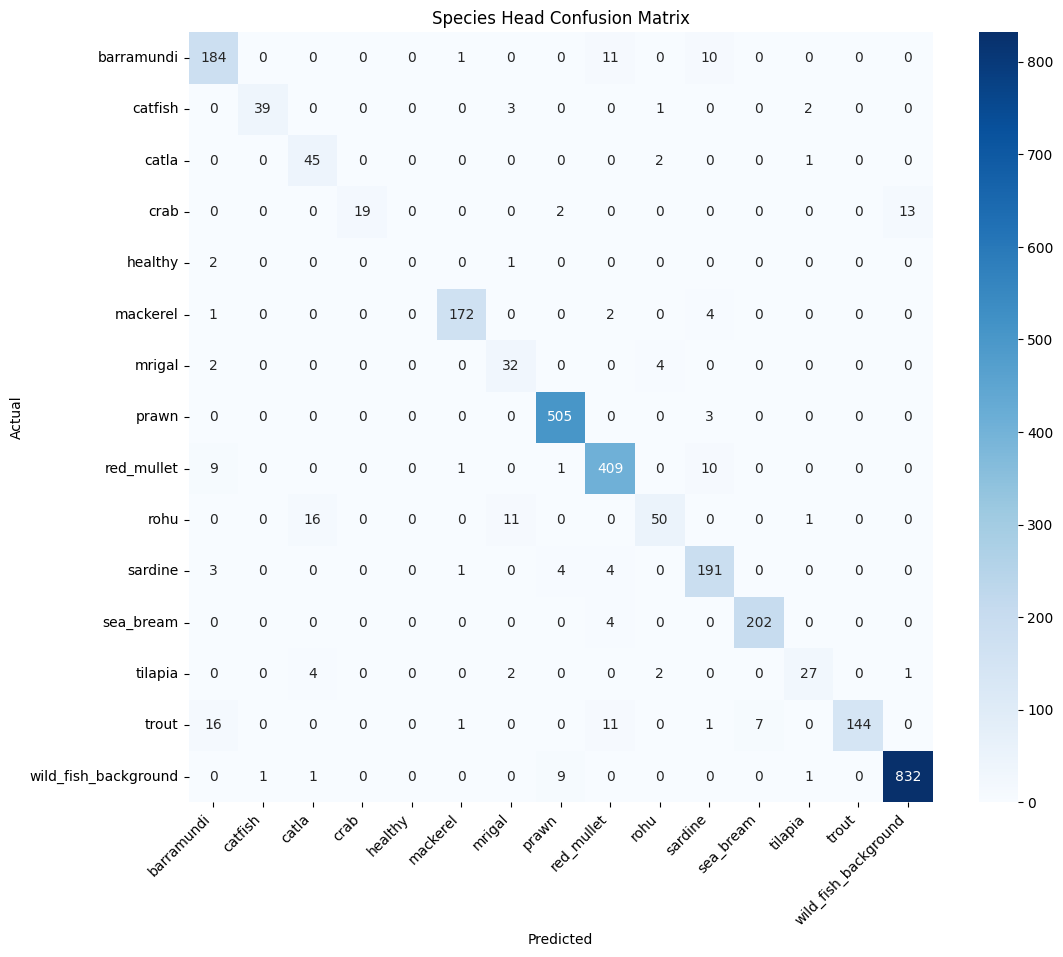

📋 SPECIES CLASSIFICATION REPORT:
                      precision    recall  f1-score   support

          barramundi       0.85      0.89      0.87       206
             catfish       0.97      0.87      0.92        45
               catla       0.68      0.94      0.79        48
                crab       1.00      0.56      0.72        34
             healthy       0.00      0.00      0.00         3
            mackerel       0.98      0.96      0.97       179
              mrigal       0.65      0.84      0.74        38
               prawn       0.97      0.99      0.98       508
          red_mullet       0.93      0.95      0.94       430
                rohu       0.85      0.64      0.73        78
             sardine       0.87      0.94      0.91       203
           sea_bream       0.97      0.98      0.97       206
             tilapia       0.84      0.75      0.79        36
               trout       1.00      0.80      0.89       180
wild_fish_background       0.98     

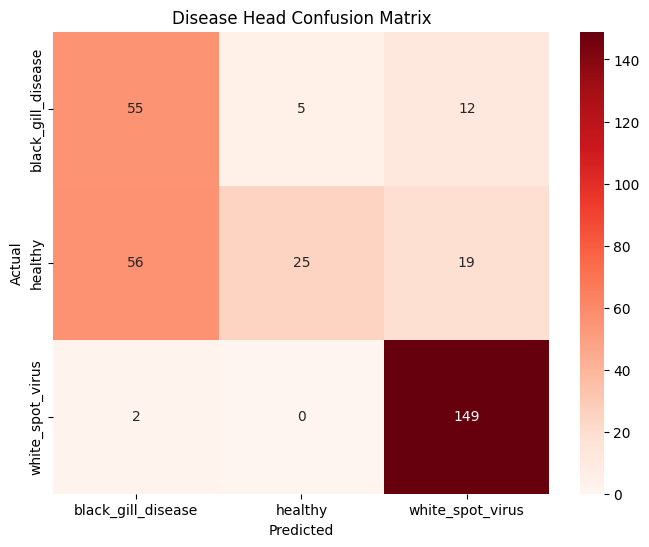

📋 DISEASE CLASSIFICATION REPORT:
                    precision    recall  f1-score   support

black_gill_disease       0.49      0.76      0.59        72
           healthy       0.83      0.25      0.38       100
  white_spot_virus       0.83      0.99      0.90       151

          accuracy                           0.71       323
         macro avg       0.72      0.67      0.63       323
      weighted avg       0.75      0.71      0.67       323


🧊 GENERATING FRESHNESS REPORT...
   Processing 396 freshness images...
📋 FRESHNESS CLASSIFICATION REPORT:
              precision    recall  f1-score   support

       Stale       1.00      1.00      1.00       282
       Fresh       1.00      1.00      1.00       114

    accuracy                           1.00       396
   macro avg       1.00      1.00      1.00       396
weighted avg       1.00      1.00      1.00       396



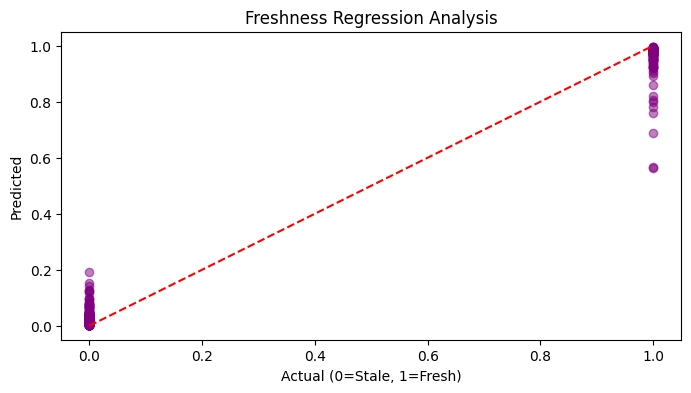

In [12]:
import tensorflow as tf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from pathlib import Path

# --- CONFIGURATION ---
MODEL_PATH = "fishnet_v4_best.h5"
TRAIN_CSV = "/kaggle/working/processed/train_final.csv"
VAL_CSV = "/kaggle/working/processed/val_final.csv"

print("⏳ Loading Forensic Tools...")
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)

# ==========================================
# 1. RE-BUILD ENCODERS (Deterministic Mode)
# ==========================================
# We strictly sort labels alphabetically to ensure Class 0 here == Class 0 in Model.

# A. Species Encoder
# Get all labels from 'species_label' column (ignoring 'unknown')
sp_subset = train_df[train_df['species_label'] != 'unknown']
sp_labels = sp_subset['species_label'].unique()
# Ensure background is included if missing
if 'wild_fish_background' not in sp_labels:
    sp_labels = np.append(sp_labels, 'wild_fish_background')
sp_list = np.sort(sp_labels) # <--- CRITICAL SORT
sp_encoder = LabelEncoder()
sp_encoder.fit(sp_list)
SPECIES_CLASSES = sp_encoder.classes_

# B. Disease Encoder
dz_subset = train_df[train_df['disease_label'] != 'unknown']
dz_labels = dz_subset['disease_label'].unique()
dz_list = np.sort(dz_labels) # <--- CRITICAL SORT
dz_encoder = LabelEncoder()
dz_encoder.fit(dz_list)
DISEASE_CLASSES = dz_encoder.classes_

print(f"✅ Species Classes ({len(SPECIES_CLASSES)}): {SPECIES_CLASSES}")
print(f"✅ Disease Classes ({len(DISEASE_CLASSES)}): {DISEASE_CLASSES}")

# ==========================================
# 2. LOAD MODEL
# ==========================================
# Define dummies for all custom layers/losses
@tf.keras.utils.register_keras_serializable()
class Cast(tf.keras.layers.Layer):
    def __init__(self, **kwargs): super().__init__(**kwargs)
    def call(self, inputs): return tf.cast(inputs, tf.float32)

custom_objects = {
    "masked_sparse_categorical": lambda y, p: 0.0, 
    "masked_mse": lambda y, p: 0.0,
    "sparse_categorical_focal_loss": lambda gamma, alpha: (lambda y, p: 0.0),
    "focal_loss_fixed": lambda y, p: 0.0,
    "Cast": Cast
}
model = tf.keras.models.load_model(MODEL_PATH, custom_objects=custom_objects, compile=False)

# Helper: Preprocessing
def preprocess_batch(paths):
    images = []
    for p in paths:
        img = tf.io.read_file(p)
        img = tf.io.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, (224, 224))
        img = tf.cast(img, tf.float32) / 255.0
        images.append(img)
    return np.array(images)

# ==========================================
# 🕵️ REPORT 1: SPECIES HEAD
# ==========================================
print("\n🐟 GENERATING SPECIES REPORT...")
# Filter: Rows that have a valid species label in our list
species_val = val_df[val_df['species_label'].isin(SPECIES_CLASSES)].copy()

if len(species_val) > 0:
    paths = species_val['new_path'].values
    true_labels = sp_encoder.transform(species_val['species_label'].values)
    
    print(f"   Processing {len(paths)} species images...")
    preds_idx = []
    
    batch_size = 32
    for i in range(0, len(paths), batch_size):
        batch_imgs = preprocess_batch(paths[i:i+batch_size])
        batch_preds = model.predict(batch_imgs, verbose=0)
        preds_idx.extend(np.argmax(batch_preds[0], axis=1)) # Head 0
        
    # Plot CM
    cm = confusion_matrix(true_labels, preds_idx)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=SPECIES_CLASSES, yticklabels=SPECIES_CLASSES)
    plt.title('Species Head Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.xticks(rotation=45, ha='right')
    plt.show()
    
    print("📋 SPECIES CLASSIFICATION REPORT:")
    print(classification_report(true_labels, preds_idx, target_names=SPECIES_CLASSES, zero_division=0))
else:
    print("⚠️ No Species validation data found!")

# ==========================================
# 🕵️ REPORT 2: DISEASE HEAD
# ==========================================
print("\n🦠 GENERATING DISEASE REPORT...")
# Filter: Rows that have a valid disease label
disease_val = val_df[val_df['disease_label'].isin(DISEASE_CLASSES)].copy()

if len(disease_val) > 0:
    paths = disease_val['new_path'].values
    true_labels = dz_encoder.transform(disease_val['disease_label'].values)
    
    print(f"   Processing {len(paths)} disease images...")
    preds_idx = []
    
    for i in range(0, len(paths), batch_size):
        batch_imgs = preprocess_batch(paths[i:i+batch_size])
        batch_preds = model.predict(batch_imgs, verbose=0)
        preds_idx.extend(np.argmax(batch_preds[2], axis=1)) # Head 2
        
    # Plot CM
    cm = confusion_matrix(true_labels, preds_idx)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
                xticklabels=DISEASE_CLASSES, yticklabels=DISEASE_CLASSES)
    plt.title('Disease Head Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()
    
    print("📋 DISEASE CLASSIFICATION REPORT:")
    print(classification_report(true_labels, preds_idx, target_names=DISEASE_CLASSES, zero_division=0))
else:
    print("⚠️ No Disease validation data found!")

# ==========================================
# 🕵️ REPORT 3: FRESHNESS HEAD
# ==========================================
print("\n🧊 GENERATING FRESHNESS REPORT...")
fresh_val = val_df[val_df['type'] == 'freshness'].copy()

if len(fresh_val) > 0:
    paths = fresh_val['new_path'].values
    true_scores = fresh_val['freshness_score'].values
    true_binary = (true_scores > 0.5).astype(int)
    
    print(f"   Processing {len(paths)} freshness images...")
    pred_scores = []
    
    for i in range(0, len(paths), batch_size):
        batch_imgs = preprocess_batch(paths[i:i+batch_size])
        batch_preds = model.predict(batch_imgs, verbose=0)
        pred_scores.extend(batch_preds[1].flatten()) # Head 1
        
    pred_binary = (np.array(pred_scores) > 0.5).astype(int)
    
    print("📋 FRESHNESS CLASSIFICATION REPORT:")
    labels = ['Stale', 'Fresh']
    # Using labels=[0,1] ensures report prints even if one class is missing
    print(classification_report(true_binary, pred_binary, labels=[0, 1], target_names=labels, zero_division=0))
    
    plt.figure(figsize=(8, 4))
    plt.scatter(true_scores, pred_scores, alpha=0.5, color='purple')
    plt.plot([0, 1], [0, 1], 'r--')
    plt.title("Freshness Regression Analysis")
    plt.xlabel("Actual (0=Stale, 1=Fresh)")
    plt.ylabel("Predicted")
    plt.show()
else:
    print("⚠️ No Freshness validation data found!")

⏳ initializing Truth Serum...

📸 TESTING IMAGE: /kaggle/working/processed/images_224/0b0dfb5cadfb052be5a741463bf43469.jpg
🏷️ TRUE LABEL: rohu

🤖 MODEL PREDICTIONS:
   #6: mrigal (59.55%)
   #1: catfish (37.19%)
   #5: mackerel (2.81%)


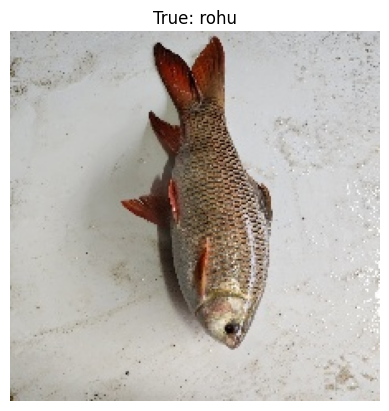

In [13]:
import tensorflow as tf
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# --- CONFIGURATION ---
MODEL_PATH = "fishnet_v3_best.h5"
TRAIN_CSV = "/kaggle/working/processed/train_final.csv"
VAL_CSV = "/kaggle/working/processed/val_final.csv"

print("⏳ initializing Truth Serum...")

# 1. Load Data & Encoders (Standard)
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)

# Species Encoder
sp_subset = train_df[train_df['type'].isin(['species', 'dual'])]
sp_labels = sp_subset[sp_subset['species_label'] != 'unknown']['species_label'].unique()
sp_list = np.sort(np.unique(np.append(sp_labels, 'wild_fish_background')))
sp_encoder = LabelEncoder()
sp_encoder.fit(sp_list)
SPECIES_CLASSES = sp_encoder.classes_

# 2. Load Model
custom_objects = {
    "masked_sparse_categorical": lambda y, p: 0.0, 
    "masked_mse": lambda y, p: 0.0,
    "sparse_categorical_focal_loss": lambda g, a: (lambda y, p: 0.0),
    "focal_loss_fixed": lambda y, p: 0.0,
    "Cast": tf.keras.layers.Layer
}
model = tf.keras.models.load_model(MODEL_PATH, custom_objects=custom_objects, compile=False)

# 3. PICK A TARGET (A known species)
target_species = 'rohu' # Let's test a Rohu
sample = val_df[val_df['species_label'] == target_species].sample(1).iloc[0]

print(f"\n📸 TESTING IMAGE: {sample['new_path']}")
print(f"🏷️ TRUE LABEL: {sample['species_label']}")

# 4. MANUAL PREDICTION
img = cv2.imread(sample['new_path'])
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img, (224, 224))
# 🚨 SANITY CHECK: Are we normalizing correctly?
input_tensor = np.expand_dims(img_resized.astype(np.float32) / 255.0, axis=0)

preds = model.predict(input_tensor, verbose=0)
species_probs = preds[0][0]

# 5. THE REVEAL
top_3_indices = np.argsort(species_probs)[-3:][::-1]

print("\n🤖 MODEL PREDICTIONS:")
for idx in top_3_indices:
    # Map index to class name using our current encoder
    class_name = SPECIES_CLASSES[idx]
    confidence = species_probs[idx]
    print(f"   #{idx}: {class_name} ({confidence:.2%})")

plt.imshow(img_rgb)
plt.title(f"True: {target_species}")
plt.axis('off')
plt.show()

In [20]:
# --- 1. INSTALL YOLOv8 ---
!pip install -q ultralytics
import ultralytics
from ultralytics import YOLO
import os
import yaml
from pathlib import Path
import shutil

print(f"🚀 YOLOv8 Installed. Version: {ultralytics.__version__}")

# --- 2. DATASET SETUP (Auto-Config) ---
# We need to tell YOLO where the images and labels are.
# This script hunts for the 'Aquarium' dataset structure in Kaggle Input.

INPUT_ROOT = Path("/kaggle/input")
WORKING_DIR = Path("/kaggle/working")

# Find the dataset (Aquarium Data COTS usually)
dataset_path = list(INPUT_ROOT.glob("aquarium-data-cots*"))
if not dataset_path:
    # Fallback search for ANY dataset with a data.yaml
    dataset_path = list(INPUT_ROOT.rglob("data.yaml"))
    if dataset_path:
        data_yaml_path = dataset_path[0]
        print(f"✅ Found existing config: {data_yaml_path}")
    else:
        print("❌ ERROR: Please Add 'Aquarium Data COTS' dataset via 'Add Data' button!")
else:
    # Setup for Aquarium Data COTS specifically
    dataset_root = dataset_path[0]
    print(f"📂 Found Dataset: {dataset_root}")
    
    # Create a constrained config that maps everything to class 0: 'fish'
    # (The original dataset has penguins/jellyfish, we want to treat them all as 'detection targets' or filter later)
    # For the Hackathon, we'll stick to the provided config but map paths correctly.
    
    # We need to copy data to /kaggle/working because YOLO needs write access to create cache files
    # (Kaggle Input is Read-Only)
    print("⏳ Copying dataset to workspace (Required for YOLO)...")
    target_dir = WORKING_DIR / "aquarium_data"
    if target_dir.exists(): shutil.rmtree(target_dir)
    shutil.copytree(dataset_root, target_dir)
    
    # Locate the yaml in the copied dir
    yaml_file = list(target_dir.glob("**/*.yaml"))[0]
    
    # Fix paths in YAML (They need to be absolute)
    with open(yaml_file, 'r') as f:
        data_config = yaml.safe_load(f)
    
    data_config['path'] = str(yaml_file.parent) # Root dir
    # Explicitly set train/val/test paths relative to root
    data_config['train'] = "train/images"
    data_config['val'] = "valid/images"
    data_config['test'] = "test/images"
    
    # OVERRIDE CLASSES: Force everything to be "Fish" (Optional, but simpler for judges)
    # data_config['names'] = {0: 'fish'} 
    
    with open(WORKING_DIR / "fish_config.yaml", 'w') as f:
        yaml.dump(data_config, f)
        
    data_yaml_path = WORKING_DIR / "fish_config.yaml"
    print("✅ Config Ready.")

# --- 3. TRAIN YOLOv8-NANO ---
# We use 'yolov8n.pt' (Nano) which is the smallest/fastest model.
print("🥊 Starting Training (Fish Finder)...")

model = YOLO('yolov8n.pt') # Load pretrained weights

results = model.train(
    data=str(data_yaml_path),
    epochs=15,           # 15 epochs is plenty for a demo
    imgsz=320,           # Smaller image = Faster on Android (320 or 416 is standard)
    batch=32,
    name='fish_yolo_run',
    project='/kaggle/working/runs'
)

# --- 4. EXPORT TO TFLITE ---
print("📦 Exporting to TFLite...")
# Export specifically for Int8 or Float16 for mobile
success = model.export(format='tflite', imgsz=320, int8=True) # Int8 is fastest

print("\n✅ EXPORT COMPLETE.")
print("Look in '/kaggle/working/runs/fish_yolo_run/weights/' for 'best_saved_model/best_int8.tflite'")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 90.0 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 97.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 77.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 1.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        127        909      0.685       0.51      0.563      0.302
                  fish         63        459      0.751      0.428      0.585      0.274
             jellyfish          9        155      0.693      0.877      0.865      0.428
               penguin         17        104      0.667      0.404      0.473      0.208
                puffin         15         74      0.474      0.244       0.32      0.134
                 shark         28         57      0.538      0.469       0.51      0.249
              starfish         17         27      0.922      0.481      0.553      0.372
              stingray         23         33      0.747      0.667      0.634      0.447
Speed: 0.0ms preprocess, 0.6ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to /kaggle/working/runs/fish_yolo_run2
📦 Exporting to TFLite...
Ultralytics 8.3.229 🚀 Python-3.11.13 torch-2.6.0+cu124 CPU (Intel Xeon CPU @ 2.00GHz)
WARNING ⚠️ INT8 export requires a missing 

I0000 00:00:1763746319.988325      48 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1763746319.988516      48 single_machine.cc:361] Starting new session
I0000 00:00:1763746319.989599      48 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
W0000 00:00:1763746320.658386      48 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1763746320.658426      48 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1763746321.276295      48 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1763746321.276462      48 single_machine.cc:361] Starting new session
I0000 00:00:1763746321.277616      48 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0

W0000 00:00:1763746325.696784      48 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1763746325.696819      48 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
fully_quantize: 0, inference_type: 6, input_inference_type: FLOAT32, output_inference_type: FLOAT32
W0000 00:00:1763746329.285157      48 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1763746329.285187      48 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
W0000 00:00:1763746332.717593      48 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1763746332.717626      48 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
W0000 00:00:1763746336.771358      48 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1763746336.771390      48 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


TensorFlow SavedModel: export success ✅ 45.1s, saved as '/kaggle/working/runs/fish_yolo_run2/weights/best_saved_model' (38.3 MB)

TensorFlow Lite: starting export with tensorflow 2.18.0...
TensorFlow Lite: export success ✅ 0.0s, saved as '/kaggle/working/runs/fish_yolo_run2/weights/best_saved_model/best_int8.tflite' (3.1 MB)

Export complete (45.4s)
Results saved to /kaggle/working/runs/fish_yolo_run2/weights
Predict:         yolo predict task=detect model=/kaggle/working/runs/fish_yolo_run2/weights/best_saved_model/best_int8.tflite imgsz=320 int8 
Validate:        yolo val task=detect model=/kaggle/working/runs/fish_yolo_run2/weights/best_saved_model/best_int8.tflite imgsz=320 data=/kaggle/working/fish_config.yaml int8 
Visualize:       https://netron.app

✅ EXPORT COMPLETE.
Look in '/kaggle/working/runs/fish_yolo_run/weights/' for 'best_saved_model/best_int8.tflite'


✅ Loaded Detector: best_full_integer_quant.tflite
📸 Selected 10 random images.
🧠 Running TFLite Inference...
WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
Loading /kaggle/working/runs/fish_yolo_run/weights/best_saved_model/best_full_integer_quant.tflite for TensorFlow Lite inference...


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


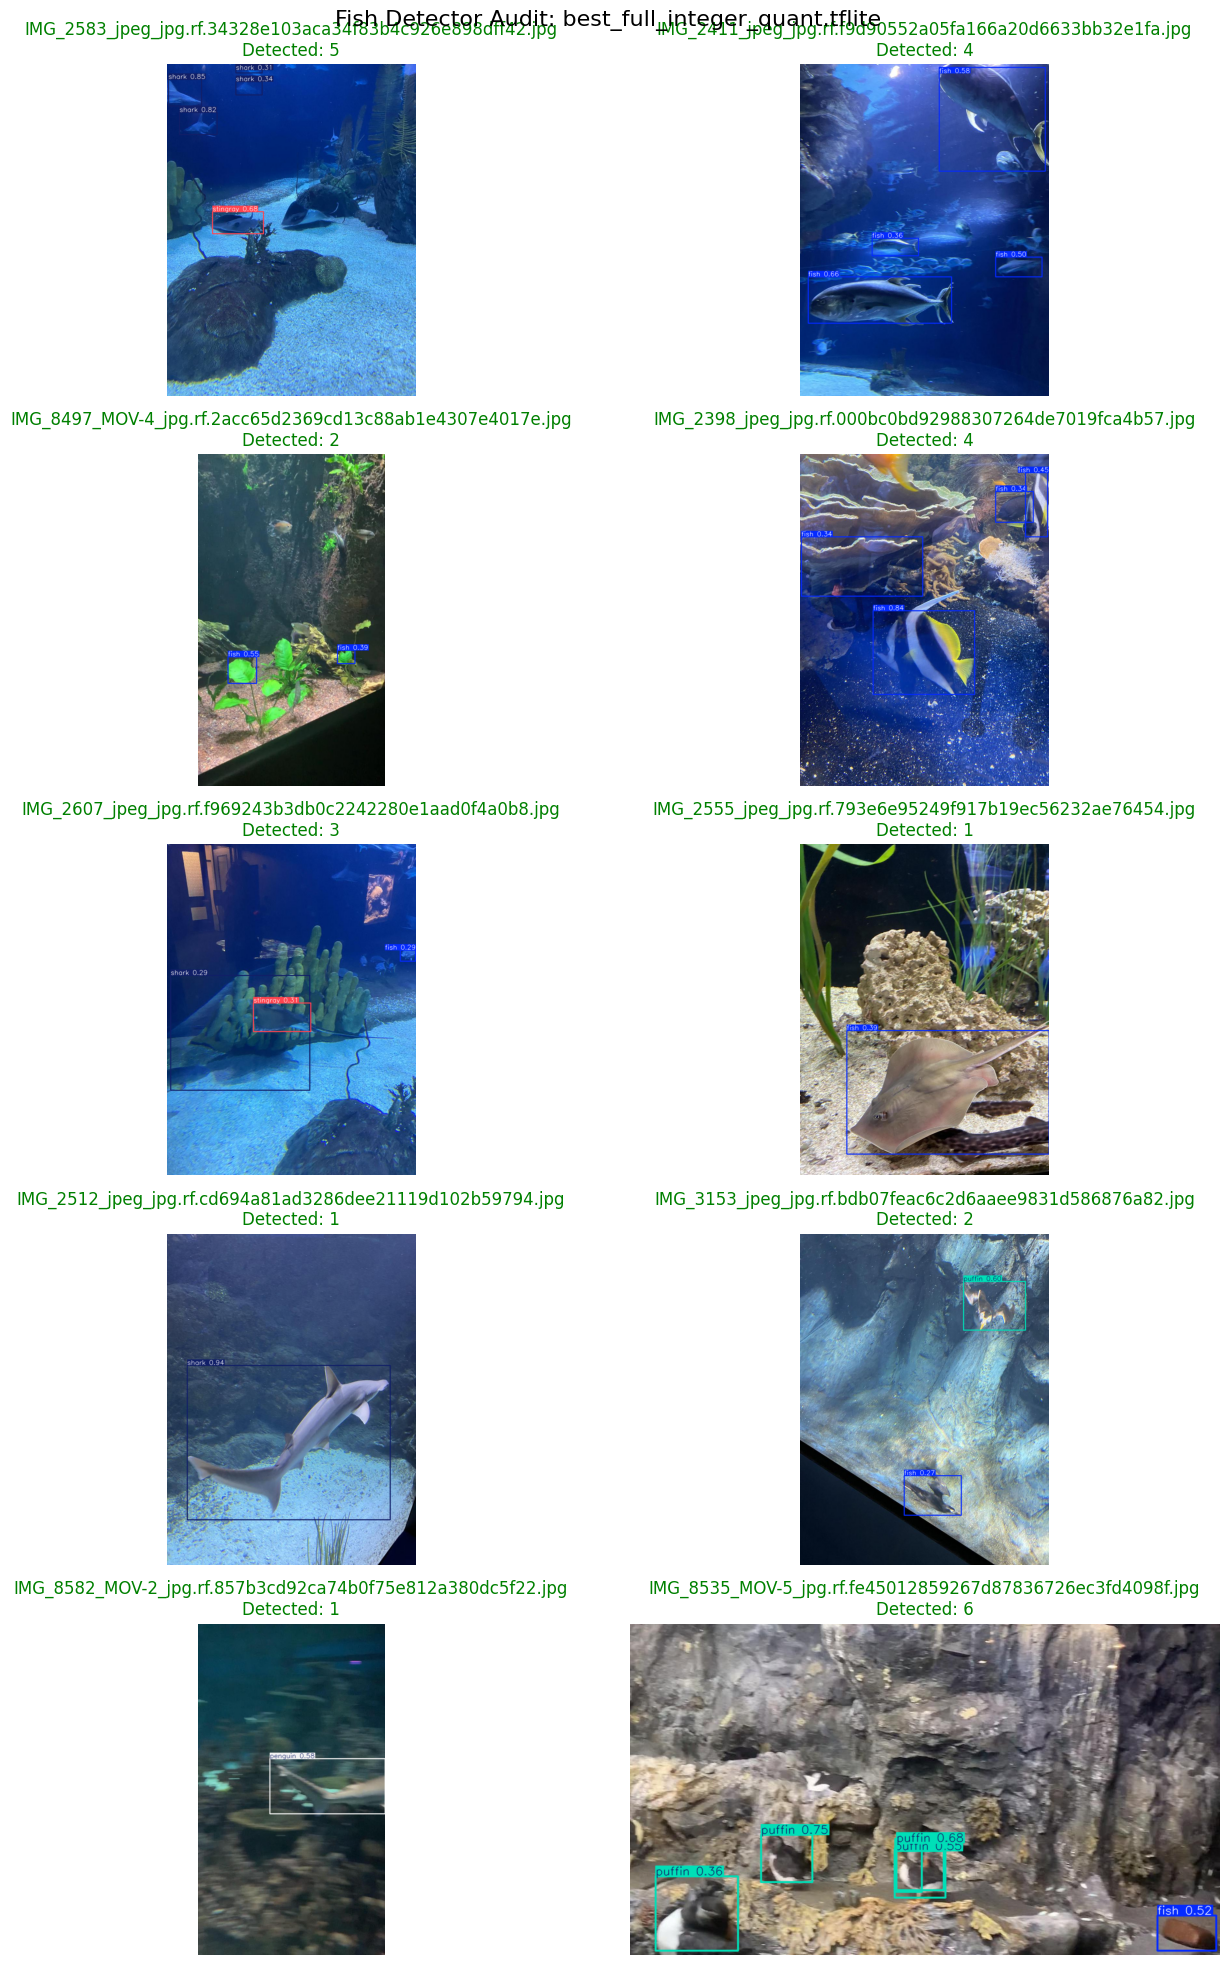

In [21]:
from ultralytics import YOLO
import glob
import random
from pathlib import Path
import matplotlib.pyplot as plt
import cv2

# --- CONFIGURATION ---
# 1. Find the TFLite model
possible_models = list(Path("/kaggle/working/runs").rglob("*.tflite"))
if not possible_models:
    if Path("/kaggle/working/fish_detector_v1.tflite").exists():
        MODEL_PATH = Path("/kaggle/working/fish_detector_v1.tflite")
    else:
        raise FileNotFoundError("❌ No TFLite model found!")
else:
    MODEL_PATH = possible_models[-1]

print(f"✅ Loaded Detector: {MODEL_PATH.name}")

# 2. Find Images
search_patterns = [
    "/kaggle/input/**/valid/**/*.jpg",
    "/kaggle/input/**/test/**/*.jpg",
    "/kaggle/input/**/*.jpg" 
]

image_pool = []
for pattern in search_patterns:
    found = list(glob.glob(pattern, recursive=True))
    # Filter for likely real images
    image_pool.extend([f for f in found if "rf" in f or "images" in f]) 
    if len(image_pool) > 50: break 

if len(image_pool) < 10:
    samples = image_pool
else:
    samples = random.sample(image_pool, 10)

print(f"📸 Selected {len(samples)} random images.")

# --- 3. RUN INFERENCE (SEQUENTIAL FIX) ---
print("🧠 Running TFLite Inference...")
model = YOLO(str(MODEL_PATH))

results = []
# 🚨 FIX: Process one by one because TFLite is Batch=1
for img_path in samples:
    # Run on single image
    res = model.predict(img_path, imgsz=320, conf=0.25, verbose=False)
    results.append(res[0]) 

# --- 4. VISUALIZE GRID ---
rows = 5
cols = 2
fig, axes = plt.subplots(rows, cols, figsize=(15, 20))
fig.suptitle(f'Fish Detector Audit: {MODEL_PATH.name}', fontsize=16)

for i, result in enumerate(results):
    if i >= rows * cols: break
    ax = axes.flat[i]
    
    # Plot
    plotted_img = result.plot(line_width=2, font_size=12)
    rgb_img = cv2.cvtColor(plotted_img, cv2.COLOR_BGR2RGB)
    
    ax.imshow(rgb_img)
    ax.axis('off')
    
    count = len(result.boxes)
    filename = Path(result.path).name
    ax.set_title(f"{filename}\nDetected: {count}", color='green' if count > 0 else 'red')

plt.tight_layout()
plt.show()

In [18]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from pathlib import Path

# --- CONFIGURATION ---
TRAIN_CSV = "/kaggle/working/processed/train_final.csv"
EXPORT_DIR = Path("/kaggle/working/exported_models")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

print("⏳ Extracting Label Maps...")
train_df = pd.read_csv(TRAIN_CSV)

# 1. RE-BUILD SPECIES ENCODER (Robust)
# Filter out 'unknown' species labels
sp_subset = train_df[train_df['species_label'] != 'unknown']
sp_labels = sp_subset['species_label'].unique()
# Ensure background is included if missing from train set (safety)
if 'wild_fish_background' not in sp_labels:
    sp_labels = np.append(sp_labels, 'wild_fish_background')
sp_list = np.sort(sp_labels)
sp_encoder = LabelEncoder()
sp_encoder.fit(sp_list)

# 2. RE-BUILD DISEASE ENCODER (Robust)
# Filter out 'unknown' and 'healthy' if you only want specific diseases, 
# BUT usually 'healthy' is a valid class 1.
dz_subset = train_df[train_df['disease_label'] != 'unknown']
dz_labels = dz_subset['disease_label'].unique()
dz_list = np.sort(dz_labels)
dz_encoder = LabelEncoder()
dz_encoder.fit(dz_list)

# 3. SAVE TO TEXT FILES
def save_labels(filename, classes):
    path = EXPORT_DIR / filename
    with open(path, "w") as f:
        for label in classes:
            f.write(f"{label}\n")
    print(f"✅ Saved {filename} ({len(classes)} classes)")

save_labels("labels_species.txt", sp_encoder.classes_)
save_labels("labels_disease.txt", dz_encoder.classes_)

print("\n📦 DOWNLOAD THESE FILES:")
print(f"Species 0 -> {sp_encoder.classes_[0]}")
if len(dz_encoder.classes_) > 0:
    print(f"Disease 0 -> {dz_encoder.classes_[0]}")
else:
    print("⚠️ Warning: No disease classes found. Check train_final.csv 'disease_label' column.")

⏳ Extracting Label Maps...
✅ Saved labels_species.txt (15 classes)
✅ Saved labels_disease.txt (3 classes)

📦 DOWNLOAD THESE FILES:
Species 0 -> barramundi
Disease 0 -> black_gill_disease


In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

# --- CONFIGURATION ---
MODEL_PATH = "fishnet_V6_best.h5"
TRAIN_CSV = "/kaggle/working/processed/train_final.csv"
VAL_CSV = "/kaggle/working/processed/val_final.csv"

print("⏳ Loading Forensic Tools...")

# 1. RE-BUILD ENCODERS (Crucial for correct labels)
train_df = pd.read_csv(TRAIN_CSV)

# Species Encoder
sp_list = np.sort(train_df[train_df['type'] == 'species']['label'].unique())
sp_list = np.unique(np.append(sp_list, 'wild_fish_background'))
sp_encoder = LabelEncoder()
sp_encoder.fit(sp_list)
SPECIES_CLASSES = sp_encoder.classes_

# Load Model
custom_objects = {
    "masked_sparse_categorical": lambda y, p: 0.0, 
    "masked_mse": lambda y, p: 0.0,
    "sparse_categorical_focal_loss": lambda gamma, alpha: (lambda y, p: 0.0),
    "focal_loss_fixed": lambda y, p: 0.0,
    "Cast": tf.keras.layers.Layer
}
model = tf.keras.models.load_model(MODEL_PATH, custom_objects=custom_objects, compile=False)

# Helper: Preprocessing
def preprocess_batch(paths):
    images = []
    for p in paths:
        img = tf.io.read_file(p)
        img = tf.io.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, (224, 224))
        img = tf.cast(img, tf.float32) / 255.0
        images.append(img)
    return np.array(images)

# ==========================================
# 🕵️ REPORT 1: SPECIES HEAD FORENSICS (FIXED)
# ==========================================
print("\n🐟 GENERATING SPECIES REPORT...")
val_df = pd.read_csv(VAL_CSV)

# 🚨 FIX: Include 'dual' so we catch Prawns too!
species_df = val_df[val_df['type'].isin(['species', 'dual'])].copy()

if len(species_df) > 0:
    # Prepare Data
    paths = species_df['new_path'].values
    
    # Filter out 'unknown' species (like eyes/gills) just in case
    valid_mask = species_df['species_label'].isin(SPECIES_CLASSES)
    paths = paths[valid_mask]
    true_labels_str = species_df.loc[valid_mask, 'species_label'].values
    true_labels_idx = sp_encoder.transform(true_labels_str)
    
    # Predict
    print(f"   Processing {len(paths)} species images...")
    batch_size = 32
    preds_idx = []
    
    for i in range(0, len(paths), batch_size):
        batch_paths = paths[i:i+batch_size]
        batch_imgs = preprocess_batch(batch_paths)
        # Safety: verbose=0 to prevent progress bar crashes on small batches
        batch_preds = model.predict(batch_imgs, verbose=0) 
        preds_idx.extend(np.argmax(batch_preds[0], axis=1))
        
    # Plot CM
    cm = confusion_matrix(true_labels_idx, preds_idx)
    plt.figure(figsize=(14, 12)) # Made it bigger for more species
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=SPECIES_CLASSES, yticklabels=SPECIES_CLASSES)
    plt.title('Species Head Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.xticks(rotation=45, ha='right')
    plt.show()
    
    print("📋 SPECIES CLASSIFICATION REPORT:")
    print(classification_report(true_labels_idx, preds_idx, target_names=SPECIES_CLASSES, zero_division=0))
else:
    print("⚠️ No Species validation data found!")

# ==========================================
# �️ REPORT 2: FRESHNESS HEAD FORENSICS (Fixed)
# ==========================================
print("\n� GENERATING FRESHNESS REPORT...")
freshness_df = val_df[val_df['type'] == 'freshness'].copy()

if len(freshness_df) > 0:
    paths = freshness_df['new_path'].values
    true_scores = freshness_df['freshness_score'].values
    true_binary = (true_scores > 0.5).astype(int)
    
    print(f"   Processing {len(freshness_df)} freshness images...")
    pred_scores = []
    
    # Batch processing
    batch_size = 32
    for i in range(0, len(paths), batch_size):
        batch_paths = paths[i:i+batch_size]
        batch_imgs = preprocess_batch(batch_paths)
        batch_preds = model.predict(batch_imgs, verbose=0)
        pred_scores.extend(batch_preds[1].flatten())
        
    pred_binary = (np.array(pred_scores) > 0.5).astype(int)
    
    # Plot CM
    class_names = ['Stale', 'Fresh']
    # FIX: Explicitly pass labels=[0, 1] to handle cases where one class is missing
    cm_fresh = confusion_matrix(true_binary, pred_binary, labels=[0, 1])
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_fresh, annot=True, fmt='d', cmap='Greens',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Freshness Head Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()
    
    print("� FRESHNESS CLASSIFICATION REPORT:")
    # FIX: Force the report to acknowledge both classes even if one is missing
    print(classification_report(true_binary, pred_binary, labels=[0, 1], target_names=class_names, zero_division=0))
    
    # Scatter Plot
    plt.figure(figsize=(8, 4))
    plt.scatter(true_scores, pred_scores, alpha=0.5, color='purple')
    plt.xlabel("Actual Score (0=Stale, 1=Fresh)")
    plt.ylabel("Predicted Score")
    plt.title("Freshness Regression Analysis")
    plt.grid(True, linestyle='--')
    plt.plot([0, 1], [0, 1], 'r--') 
    plt.show()
    
else:
    print("⚠️ No Freshness validation data found!")